[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,high_20,vol_ma,signal,return,position,strategy_return,cum_return,buy_hold
Date,,,,,,,,,,,,,
2026-02-06,302.0,302.0,282.0,298.0,3965600,313.0,4183040.0,0,0.013423,0.0,0.000000,0.971690,0.544144
2026-02-09,291.0,306.0,285.0,305.0,3171900,313.0,4166290.0,0,-0.036424,0.0,-0.000000,0.971690,0.524324
2026-02-10,283.0,298.0,279.0,297.0,2848900,313.0,4186005.0,0,-0.027491,0.0,-0.000000,0.971690,0.509910
2026-02-12,320.0,326.0,292.0,295.0,7742900,326.0,4394060.0,1,0.130742,0.0,0.000000,0.971690,0.576577
2026-02-13,299.0,311.0,291.0,300.0,4879900,326.0,4467100.0,0,-0.065625,1.0,-0.065625,0.907923,0.538739
2026-02-16,314.0,331.0,304.0,306.0,5493600,331.0,4559415.0,0,0.050167,0.0,0.000000,0.907923,0.565766
2026-02-17,327.0,341.0,313.0,317.0,4734200,341.0,4521445.0,0,0.041401,0.0,0.000000,0.907923,0.589189
2026-02-18,353.0,365.0,324.0,328.0,8145400,365.0,4743250.0,1,0.079511,0.0,0.000000,0.907923,0.636036
2026-02-19,347.0,356.0,336.0,353.0,3328900,365.0,4738830.0,0,-0.016997,1.0,-0.016997,0.892491,0.625225


Index(['Close', 'High', 'Low', 'Open', 'Volume', 'high_20', 'vol_ma', 'signal',
       'return', 'position', 'strategy_return', 'cum_return', 'buy_hold'],
      dtype='str')
None


<Axes: xlabel='Date'>

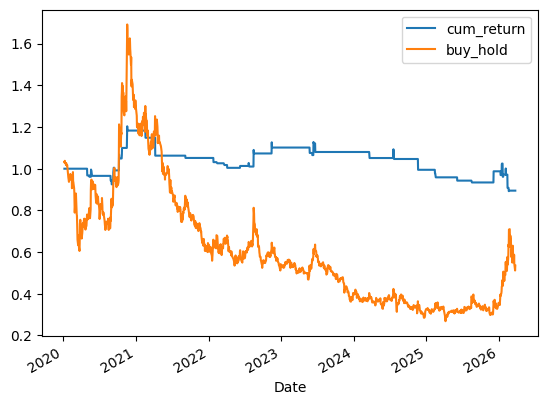

In [17]:
import yfinance as yf
df = yf.download("7779.T", start="2020-01-01", interval="1D")
df = df.copy()
df.columns = df.columns.get_level_values(0)
df.columns.name = None

# 過去20日高値
df["high_20"] = df["High"].rolling(20).max()

# 出来高平均
df["vol_ma"] = df["Volume"].rolling(20).mean()


# シグナル
df["signal"] = (
    (df["Close"] > df["high_20"].shift(1)) & 
    (df["Volume"] > df["vol_ma"])
).astype(int)

#仮バックテスト
# リターン
df["return"] = df["Close"].pct_change()

# ポジション
df["position"] = df["signal"].shift(1)

# 戦略リターン
df["strategy_return"] = df["position"] * df["return"]

# 累積
df["cum_return"] = (1 + df["strategy_return"]).cumprod()

# 比較
df["buy_hold"] = (1 + df["return"]).cumprod()


display(df.tail(30))
print(df.columns)
print(df.columns.name)
df[["cum_return", "buy_hold"]].plot()
